In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import os

In [3]:
# Set Working Directory containing the Harvard Dataverse Files 
os.chdir("C:/Users/divya/Downloads/Uni/ST2195/ST2195/Coursework/dataverse_files")
os.getcwd()

'C:\\Users\\divya\\Downloads\\Uni\\ST2195\\ST2195\\Coursework\\dataverse_files'

In [5]:
# Remove any existing database named 'airline2_python.db'
try:
   os.remove('airline2_python.db')
except OSError:
    pass

In [7]:
# Create a connection to the database named 'airline2_python.db'

conn = sqlite3.connect('airline2_python.db')

In [9]:
# Create tables for the data in the dataverse
airports = pd.read_csv("airports.csv")
carriers = pd.read_csv("carriers.csv")
planes = pd.read_csv("plane-data.csv")

airports.to_sql('airports', con = conn, index = False)
carriers.to_sql('carriers', con = conn, index = False)
planes.to_sql('planes', con = conn, index = False)

5029

In [11]:
c = conn.cursor()

In [15]:
# Load data from csv.bz2 files

for year in range(2002, 2007):
    filename = str(year)+".csv.bz2"
    print('Processing:', filename)
    ontime = pd.read_csv(filename, encoding="latin-1", compression='bz2') 
    ontime.to_sql('ontime', con = conn, if_exists = 'append', index = False)

conn.commit()

Processing: 2002.csv.bz2
Processing: 2003.csv.bz2


C:\Users\divya\AppData\Local\Temp\ipykernel_2392\1543934514.py:6: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  ontime = pd.read_csv(filename, encoding="latin-1", compression='bz2')


Processing: 2004.csv.bz2
Processing: 2005.csv.bz2
Processing: 2006.csv.bz2


C:\Users\divya\AppData\Local\Temp\ipykernel_2392\1806880468.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


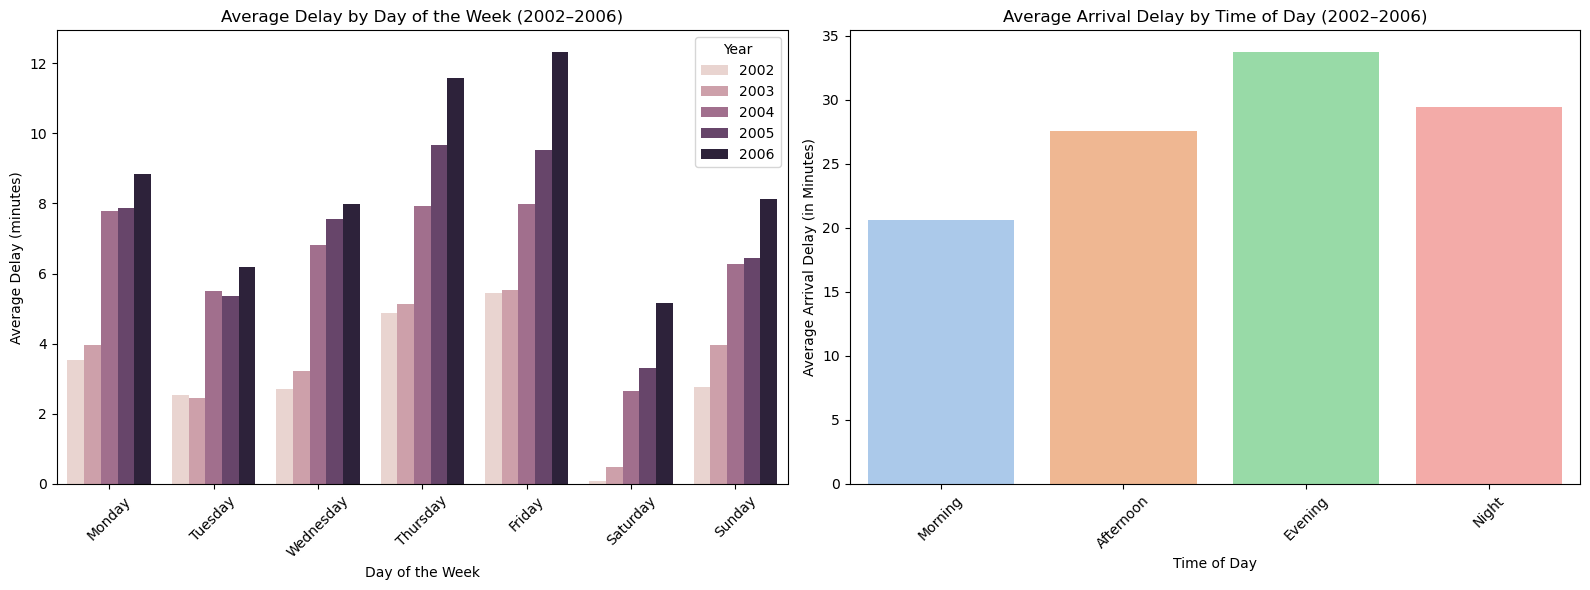

In [22]:
## Part 2(a)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Query from SQLite
query = """
SELECT Year, DayOfWeek, CRSDepTime, ArrDelay
FROM ontime
WHERE Year BETWEEN 2002 AND 2006
"""
df = pd.read_sql_query(query, conn)

# Day labels
day_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Average Delay by Day of Week
avg_delay_by_day = (
    df.groupby(['Year', 'DayOfWeek'])['ArrDelay']
    .mean()
    .reset_index()
    .rename(columns={"ArrDelay": "AvgDelay"})
)
avg_delay_by_day["DayOfWeek"] = avg_delay_by_day["DayOfWeek"].astype(int)
avg_delay_by_day["DayName"] = avg_delay_by_day["DayOfWeek"].apply(lambda x: day_labels[x - 1])

# Average Delay by Time of Day
delays_filtered = df[df["ArrDelay"] > 0].copy()

def get_time_of_day(dep_time):
    try:
        time = int(dep_time)
        if 500 <= time <= 1159:
            return "Morning"
        elif 1200 <= time <= 1659:
            return "Afternoon"
        elif 1700 <= time <= 2059:
            return "Evening"
        else:
            return "Night"
    except:
        return None

delays_filtered["TimeOfDay"] = delays_filtered["CRSDepTime"].apply(get_time_of_day)
delays_filtered["Day"] = delays_filtered["DayOfWeek"].apply(lambda x: day_labels[int(x) - 1])

avg_delay_by_time = (
    delays_filtered
    .groupby(["TimeOfDay"])["ArrDelay"]
    .mean()
    .reindex(["Morning", "Afternoon", "Evening", "Night"])  # ensure order
    .reset_index()
    .rename(columns={"ArrDelay": "AvgDelay"})
)

# Plotting graphs Side by Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A) Bar plot: Avg delay by day of week
sns.barplot(
    data=avg_delay_by_day,
    x="DayName", y="AvgDelay", hue="Year",
    ax=axes[0]
)
axes[0].set_title("Average Delay by Day of the Week (2002–2006)")
axes[0].set_ylabel("Average Delay (minutes)")
axes[0].set_xlabel("Day of the Week")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Year")

# B) Bar plot: Avg delay by time of day
sns.barplot(
    data=avg_delay_by_time,
    x="TimeOfDay", y="AvgDelay",
    palette="pastel",
    ax=axes[1]
)
axes[1].set_title("Average Arrival Delay by Time of Day (2002–2006)")
axes[1].set_ylabel("Average Arrival Delay (in Minutes)")
axes[1].set_xlabel("Time of Day")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend_.remove() if axes[1].legend_ else None

plt.tight_layout()
plt.show()


Processing year: 2002
Year 2002: A correlation coefficient of 0.83 indicates a moderate positive correlation between aircraft age and arrival delay.
Processing year: 2003
Year 2003: A correlation coefficient of 0.63 indicates a moderate positive correlation between aircraft age and arrival delay.
Processing year: 2004
Year 2004: A correlation coefficient of 0.55 indicates a moderate positive correlation between aircraft age and arrival delay.
Processing year: 2005
Year 2005: A correlation coefficient of 0.13 indicates a weak positive correlation between aircraft age and arrival delay.
Processing year: 2006
Year 2006: A correlation coefficient of 0.22 indicates a weak positive correlation between aircraft age and arrival delay.


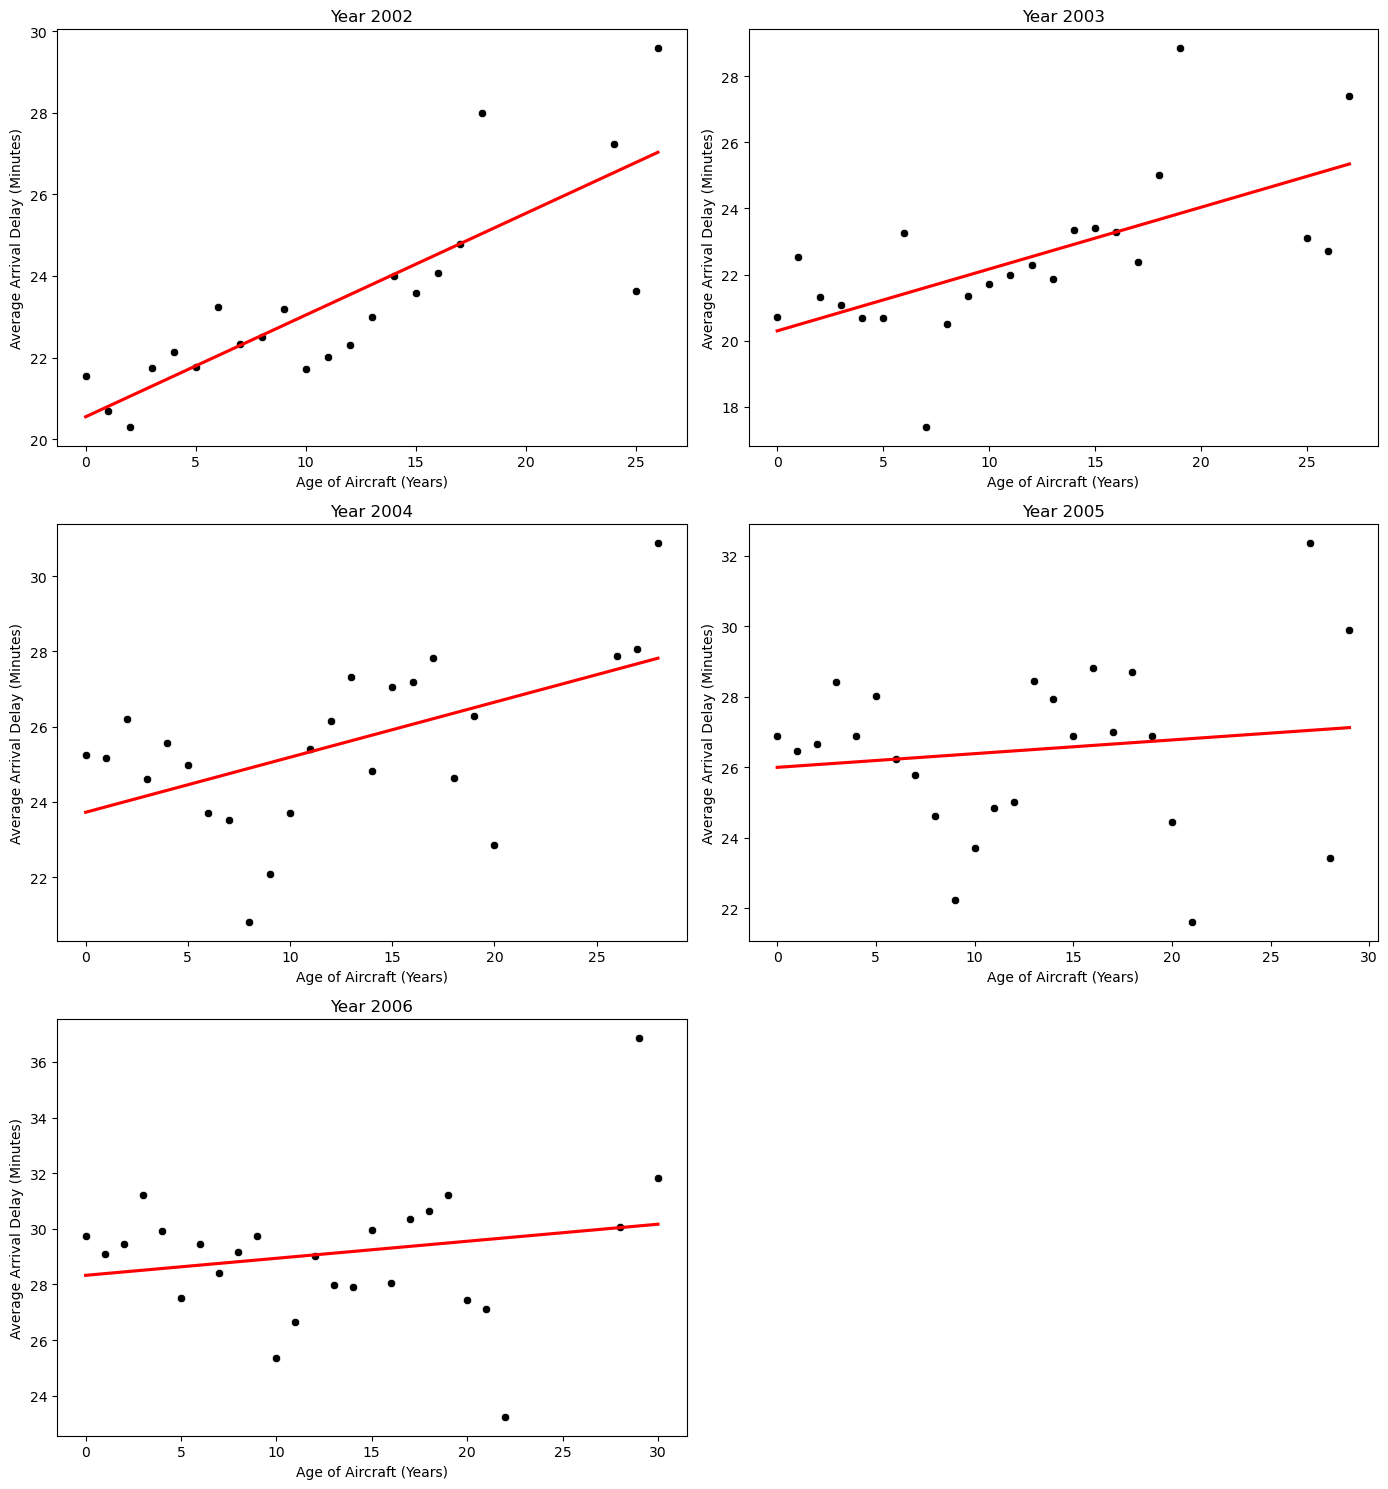

In [26]:
## Part 2(b)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import os

# Load and clean plane data
planes = pd.read_csv("plane-data.csv")
planes.columns = planes.columns.str.lower()

# Convert issue_date to datetime and extract issue year
planes["issue_date"] = pd.to_datetime(planes["issue_date"], errors='coerce')
planes["issue_year"] = planes["issue_date"].dt.year
planes = planes.dropna(subset=["issue_year"])  # keep rows with valid issue_year
planes["issue_year"] = planes["issue_year"].astype(int)

# Setting up range
years = range(2002, 2007)
plot_data_list = []
correlation_summary = []

# Process each year one by one
for year in years:
    print(f"Processing year: {year}")
    filename = f"{year}.csv.bz2"
    try:
        ontime = pd.read_csv(filename, encoding="latin-1", compression="bz2", usecols=["TailNum", "ArrDelay", "Year"])
    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue
    
    # Rename and clean
    ontime = ontime.rename(columns={"TailNum": "tailnum", "ArrDelay": "arr_delay", "Year": "flight_year"})
    ontime = ontime.dropna(subset=["tailnum", "arr_delay"])
    ontime = ontime[ontime["arr_delay"] >= 0]

    # Join with planes to get age
    merged = pd.merge(ontime, planes, how="inner", on="tailnum")
    merged["plane_age"] = merged["flight_year"] - merged["issue_year"]
    merged = merged[merged["plane_age"] >= 0]

    # Group and compute average delay by plane age
    grouped = merged.groupby("plane_age")["arr_delay"].mean().reset_index()
    grouped = grouped.dropna()

    if grouped.shape[0] < 2:
        continue

    plot_data_list.append((year, grouped))

    # Correlation
    r_value, _ = pearsonr(grouped["plane_age"], grouped["arr_delay"])
    if r_value > 0.87:
        label = "strong positive"
    elif r_value > 0.5:
        label = "moderate positive"
    elif r_value > 0:
        label = "weak positive"
    elif r_value > -0.5:
        label = "weak negative"
    elif r_value > -0.87:
        label = "moderate negative"
    else:
        label = "strong negative"

    print(f"Year {year}: A correlation coefficient of {r_value:.2f} indicates a {label} correlation between aircraft age and arrival delay.")
    correlation_summary.append((year, r_value, label))

# Plotting all years together
num_plots = len(plot_data_list)
cols = 2
rows = (num_plots + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

for i, (year, data) in enumerate(plot_data_list):
    ax = axes[i]
    sns.scatterplot(data=data, x="plane_age", y="arr_delay", color="black", ax=ax)
    sns.regplot(data=data, x="plane_age", y="arr_delay", scatter=False, ax=ax, color="red", ci=None)
    ax.set_title(f"Year {year}")
    ax.set_xlabel("Age of Aircraft (Years)")
    ax.set_ylabel("Average Arrival Delay (Minutes)")

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Processing year: 2002
Processing year: 2003
Processing year: 2004
Processing year: 2005
Processing year: 2006


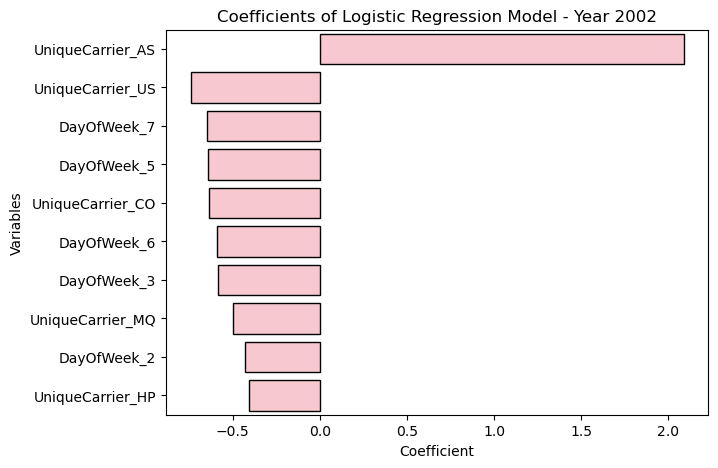

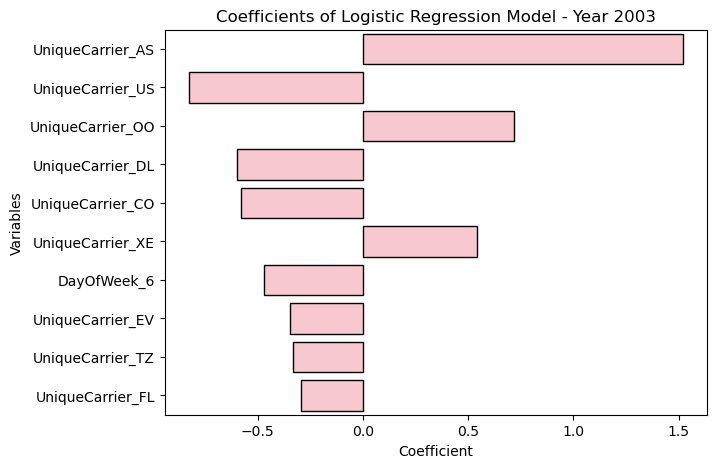

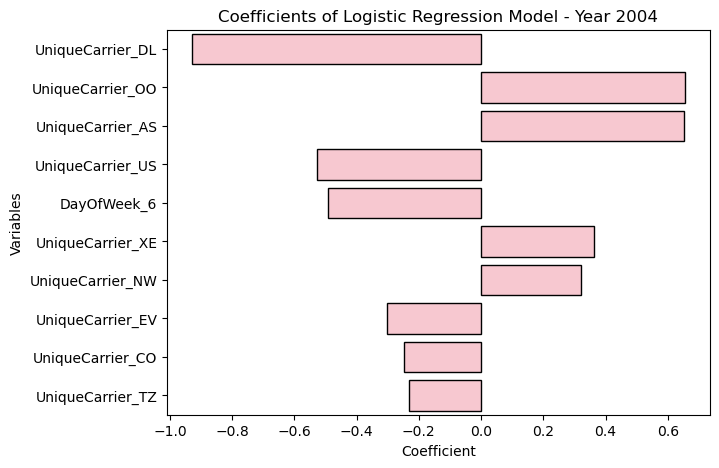

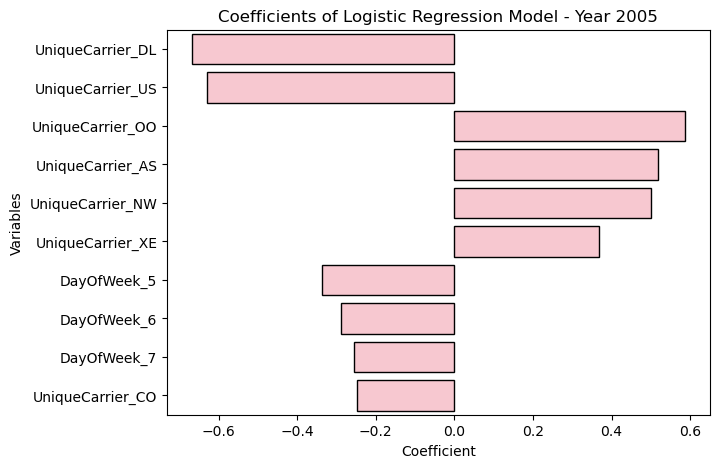

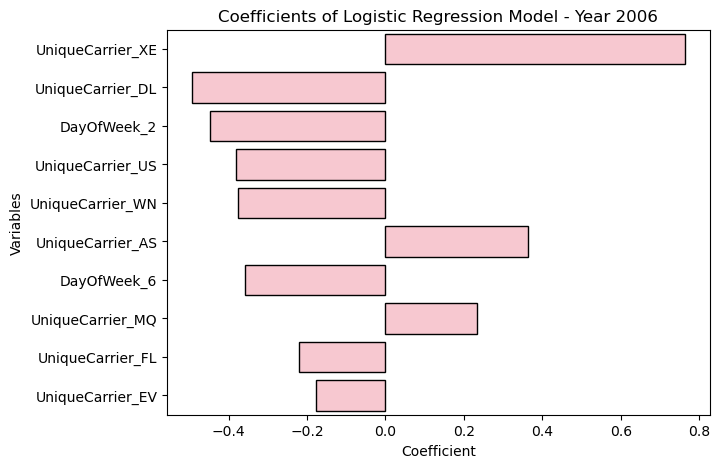

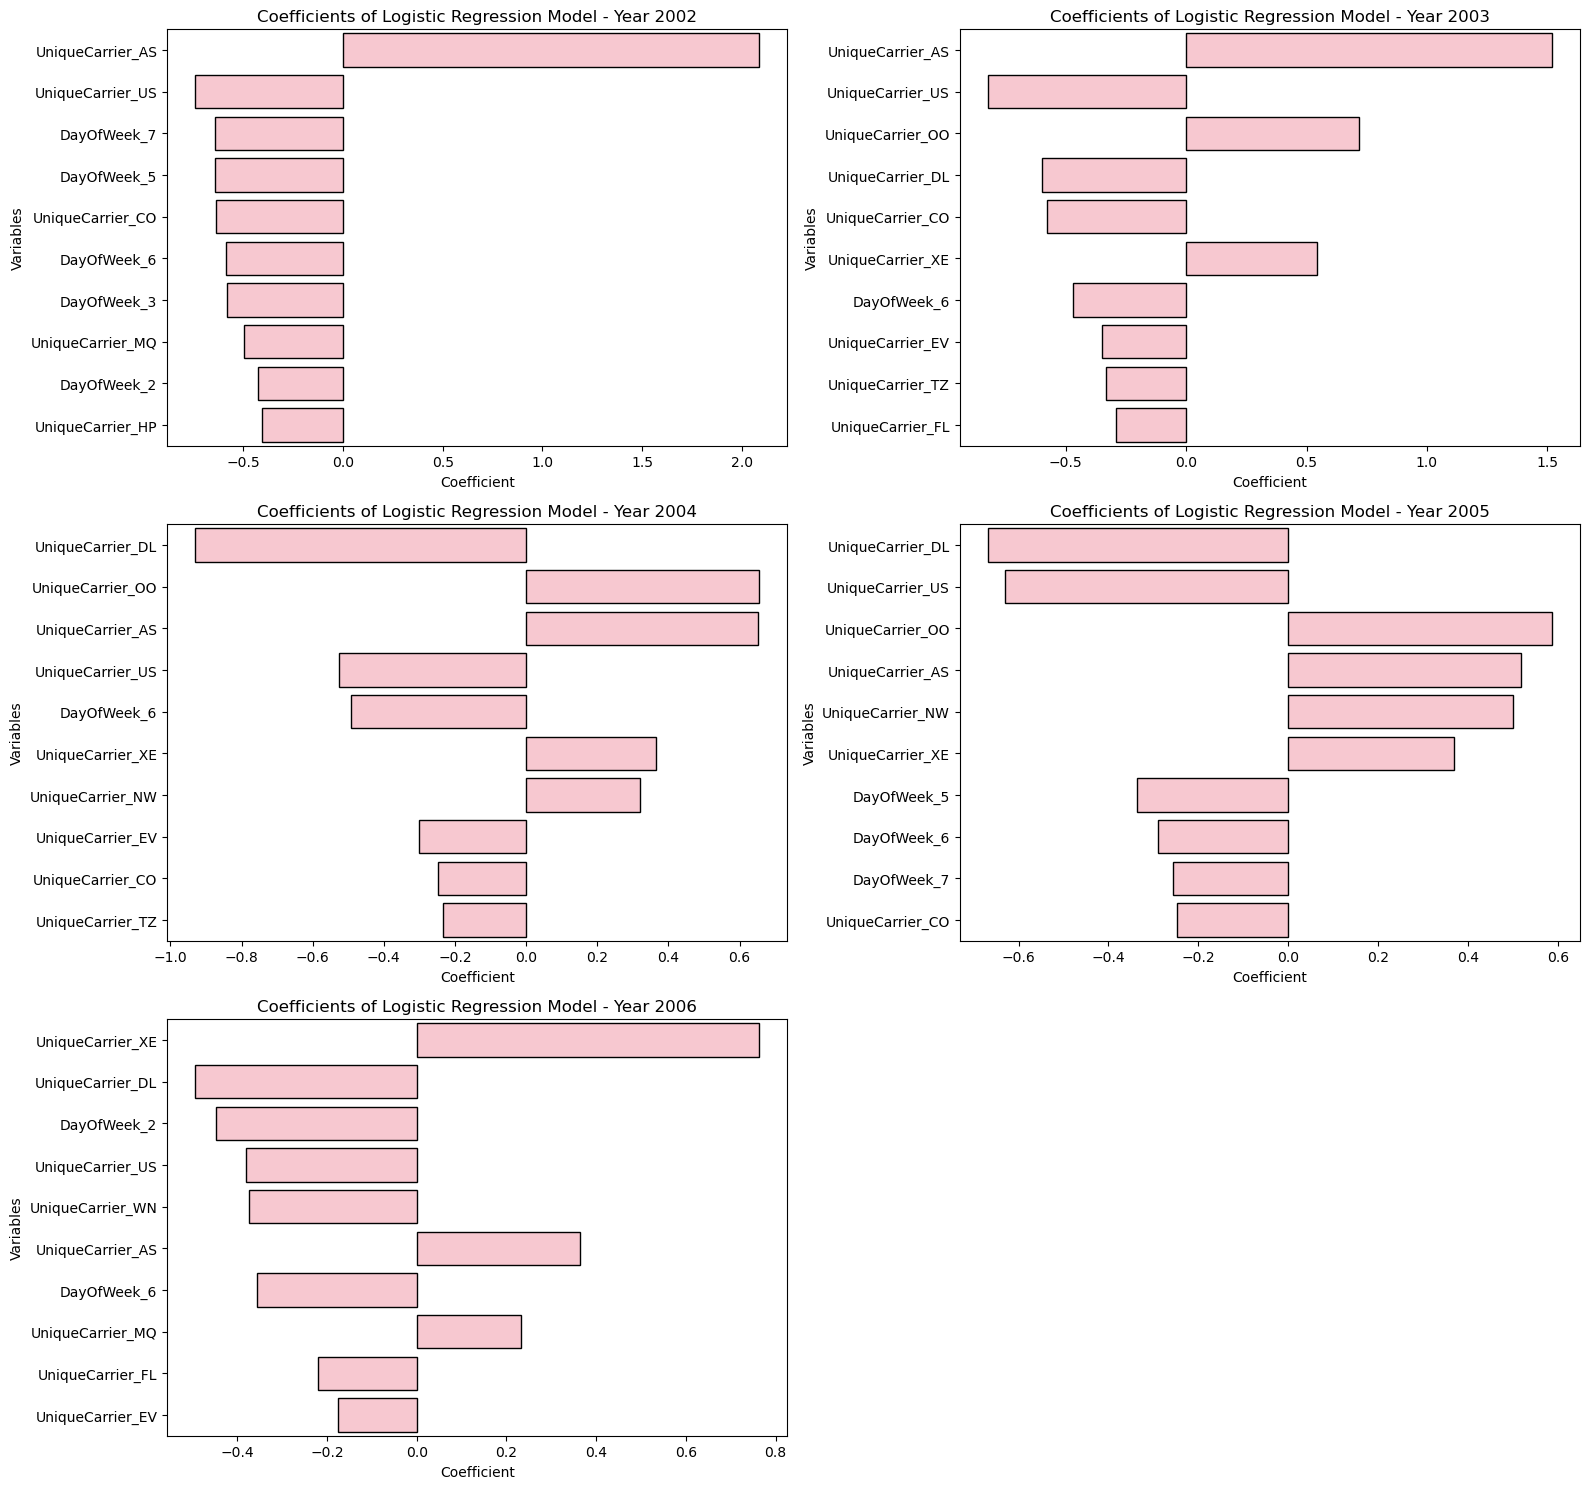

In [34]:
## Part 2(c)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load airport coordinates
airports = pd.read_csv("airports.csv")[["iata", "lat", "long"]].dropna()
airports = airports.rename(columns={"iata": "IATA", "lat": "latitude", "long": "longitude"})
airports_origin = airports.rename(columns={"IATA": "Origin", "latitude": "origin_lat", "longitude": "origin_lon"})
airports_dest = airports.rename(columns={"IATA": "Dest", "latitude": "dest_lat", "longitude": "dest_lon"})

# Main loop for 5 years range
years = range(2002, 2007)
plot_list = []
top_n = 10

for year in years:
    print(f"Processing year: {year}")
    filename = f"{year}.csv.bz2"

    try:
        ontime = pd.read_csv(filename, encoding="latin-1", compression="bz2", low_memory=False,
                             usecols=["Diverted", "Month", "DayOfWeek", "CRSDepTime", "CRSArrTime",
                                      "Distance", "Origin", "Dest", "UniqueCarrier"])
    except Exception as e:
        print(f"Failed to load {filename}: {e}")
        continue

    ontime = ontime.dropna(subset=["Diverted", "Month", "DayOfWeek", "CRSDepTime", "CRSArrTime",
                                   "Distance", "Origin", "Dest", "UniqueCarrier"])
    ontime = ontime[ontime["Distance"] > 0]
    ontime["diverted_flag"] = ontime["Diverted"].astype(int)
    ontime["dep_hour"] = ontime["CRSDepTime"] // 100
    ontime["arr_hour"] = ontime["CRSArrTime"] // 100

    ontime = ontime.merge(airports_origin, on="Origin", how="inner")
    ontime = ontime.merge(airports_dest, on="Dest", how="inner")

    features = ["Month", "DayOfWeek", "dep_hour", "arr_hour", "Distance",
                "origin_lat", "origin_lon", "dest_lat", "dest_lon", "UniqueCarrier"]
    X = ontime[features]
    y = ontime["diverted_flag"]

    categorical = ["DayOfWeek", "UniqueCarrier"]
    numeric = [col for col in features if col not in categorical]

    preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="mean"), numeric),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical)
    ])
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("logreg", LogisticRegression(max_iter=1000, solver="lbfgs")) 
    ])
    pipeline.fit(X, y)

    model = pipeline.named_steps["logreg"]
    feature_names_num = numeric
    feature_names_cat = pipeline.named_steps["preprocess"].transformers_[1][1].get_feature_names_out(categorical)
    all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

    coef_df = pd.DataFrame({
        "term": all_feature_names,
        "estimate": model.coef_[0]
    })
    coef_df["abs_estimate"] = coef_df["estimate"].abs()
    coef_df = coef_df.sort_values("abs_estimate", ascending=False).head(top_n)

    # Plot all the graphs
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(data=coef_df, x="estimate", y="term", color="pink", edgecolor="black", ax=ax)
    ax.set_title(f"Coefficients of Logistic Regression Model - Year {year}")
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Variables")
    plot_list.append(fig)

# Arrange all the graphs together
rows = (len(plot_list) + 1) // 2
fig, axs = plt.subplots(rows, 2, figsize=(16, 5 * rows))
axs = axs.flatten()

for i, plot in enumerate(plot_list):
    plot_axes = plot.axes[0]
    coef_df = pd.DataFrame({
        "term": [t.get_text() for t in plot_axes.get_yticklabels()],
        "estimate": [bar.get_width() for bar in plot_axes.patches]
    })

    sns.barplot(data=coef_df, x="estimate", y="term", ax=axs[i], color="pink", edgecolor="black")
    axs[i].set_title(plot_axes.get_title())
    axs[i].set_xlabel("Coefficient")
    axs[i].set_ylabel("Variables")

for j in range(i + 1, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()
